<div style="background: linear-gradient(135deg, #0D1B6E, #3D5AFE); padding: 30px; border-radius: 12px; margin-bottom: 20px;">
<h1 style="color: #00E5FF; font-size: 2.2em; margin:0;">🧹 Deep Dive into Data Cleaning & EDA</h1>
<h3 style="color: #9FA8DA; margin-top: 10px; font-weight: normal;">Google Developer Groups — Data Science & ML Community</h3>
<h5 style="color: #9FA8DA; margin-top: 10px; font-weight: normal;">Prepared by Oluwafemi ABIONA</h5>
<p style="color: #B3C8FF; margin-top: 8px; font-size: 1.05em;">
  <strong>Dataset:</strong> Retail Sales Transactions — 2,018 rows · 18 columns<br>
  <strong>Covers:</strong> Missing Values · Duplicates · Outliers · EDA · Correlation · Insights · ML Prep
</p>
</div>

## 📚 Table of Contents
1. [Setup & Imports](#1-setup)
2. [Load & Inspect the Dataset](#2-load)
3. [Handling Missing Values](#3-missing)
4. [Detecting Duplicates & Inconsistencies](#4-duplicates)
5. [Working with Outliers](#5-outliers) — IQR · Isolation Forest · Binning
6. [EDA Fundamentals](#6-eda) — Univariate · Bivariate · Multivariate
7. [Visualisation Techniques](#7-viz)
8. [Correlation Analysis](#8-correlation)
9. [Extracting Business Insights](#9-insights)
10. [ML-Ready Pipeline](#10-ml)


<a id="1-setup"></a>
## ⚙️ 1. Setup & Imports

In [ ]:
# !pip install missingno

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# GDG-inspired colour palette
GDG_PAL = ['#3D5AFE','#00E5FF','#FF6D00','#76FF03','#FF1744','#E040FB']
sns.set_theme(style='darkgrid', palette=GDG_PAL)
plt.rcParams.update({
    'figure.facecolor': '#0D1B6E',
    'axes.facecolor':   '#131F7A',
    'axes.titlecolor':  'white',
    'axes.labelcolor':  '#9FA8DA',
    'xtick.color':      '#9FA8DA',
    'ytick.color':      '#9FA8DA',
    'text.color':       'white',
    'grid.color':       '#1A2E8A',
    'figure.dpi':       120,
})

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


<a id="2-load"></a>
## 📥 2. Load & Inspect the Dataset

The sales dataset simulates a realistic retail operation with **injected data quality issues** — missing values, duplicates, string inconsistencies, and revenue outliers.

In [54]:
df = pd.read_csv('sales_data.csv', parse_dates=['OrderDate'])

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['OrderDate'].min().date()} → {df['OrderDate'].max().date()}")
df.head()

Shape: 2,018 rows × 18 columns
Date range: 2023-01-01 → 2025-04-12


,OrderID,OrderDate,Region,City,Category,SalesRep,Channel,PaymentMethod,UnitPrice,Quantity,Discount,ShippingCost,CustomerAge,CustomerGender,ReturnFlag,Rating,Revenue,Profit
0,ORD-10000,2023-01-01 00:00:00,South,Port Harcourt,Furniture,Rep_19,In-Store,Card,"1,157.28",3,0.00,84.66,18.00,Male,1,5.00,"3,471.84",498.46
1,ORD-10001,2023-01-01 10:00:00,Central,Kaduna,Sports,Rep_08,Wholesale,BNPL,562.06,4,0.05,348.85,33.00,Female,0,4.00,"2,135.83",351.30
2,ORD-10002,2023-01-01 20:00:00,NaN,Kano,Clothing,Rep_07,Wholesale,Card,50.11,5,0.00,83.06,53.00,Male,0,5.00,250.55,71.91
3,ORD-10003,2023-01-02 06:00:00,East,Kaduna,Furniture,Rep_16,In-Store,Card,182.77,12,0.20,72.84,58.00,Male,0,4.00,"1,754.59",433.48
4,ORD-10004,2023-01-02 16:00:00,North,Port Harcourt,Groceries,Rep_19,In-Store,Card,349.26,7,0.05,223.03,45.00,Male,0,3.00,"2,322.58",898.04


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   OrderID         2018 non-null   object        
 1   OrderDate       2018 non-null   datetime64[ns]
 2   Region          1978 non-null   object        
 3   City            2018 non-null   object        
 4   Category        2018 non-null   object        
 5   SalesRep        2018 non-null   object        
 6   Channel         2018 non-null   object        
 7   PaymentMethod   2018 non-null   object        
 8   UnitPrice       2018 non-null   float64       
 9   Quantity        2018 non-null   int64         
 10  Discount        2018 non-null   float64       
 11  ShippingCost    1937 non-null   float64       
 12  CustomerAge     1797 non-null   float64       
 13  CustomerGender  2018 non-null   object        
 14  ReturnFlag      2018 non-null   int64         
 15  Rati

In [56]:
# Statistical overview
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
OrderID,2018,2000,ORD-11866,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderDate,2018,NaN,NaN,NaN,2024-02-22 12:25:16.352824320,2023-01-01 00:00:00,2023-07-29 06:30:00,2024-02-23 03:00:00,2024-09-18 03:30:00,2025-04-12 22:00:00,NaN
Region,1978,5,North,525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,2018,8,Lagos,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,2018,7,Electronics,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SalesRep,2018,30,Rep_26,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel,2018,4,Online,876,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,2018,4,Card,794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,"2,018.00",NaN,NaN,NaN,391.30,7.96,118.47,238.24,471.94,"6,055.78",480.93
Quantity,"2,018.00",NaN,NaN,NaN,5.06,1.00,2.00,4.00,7.00,20.00,3.87


In [59]:
# Statistical overview
df.describe(include=['integer', 'float']).T.head(20)

,count,mean,std,min,25%,50%,75%,max
UnitPrice,"2,018.00",391.30,480.93,7.96,118.47,238.24,471.94,"6,055.78"
Quantity,"2,018.00",5.06,3.87,1.00,2.00,4.00,7.00,20.00
Discount,"2,018.00",0.06,0.07,0.00,0.00,0.05,0.10,0.25
ShippingCost,"1,937.00",344.03,350.07,0.15,94.58,237.94,473.42,"2,833.13"
CustomerAge,"1,797.00",35.35,11.16,18.00,27.00,35.00,43.00,74.00
ReturnFlag,"2,018.00",0.13,0.33,0.00,0.00,0.00,0.00,1.00
Rating,"1,877.00",3.87,1.11,1.00,3.00,4.00,5.00,5.00
Revenue,"2,018.00","2,500.57","9,867.35",7.56,357.64,816.52,"2,139.58","197,764.16"
Profit,"2,018.00",461.88,861.49,1.69,73.11,189.61,490.78,"13,090.06"


In [60]:
# Quick revenue summary
print(f"Total Revenue:  ₦{df['Revenue'].sum():>13,.2f}")
print(f"Total Profit:   ₦{df['Profit'].sum():>13,.2f}")
print(f"Avg Order Value:₦{df['Revenue'].mean():>13,.2f}")
print(f"Unique Products: {df['Category'].nunique()} categories")
print(f"Unique Reps:     {df['SalesRep'].nunique()}")

Total Revenue:  ₦ 5,046,146.44
Total Profit:   ₦   932,068.59
Avg Order Value:₦     2,500.57
Unique Products: 7 categories
Unique Reps:     30


In [61]:
print(f"Unique Products: {df['Category'].unique()}")
print(f"Unique Products: {df['SalesRep'].unique()}")

Unique Products: ['Furniture' 'Sports' 'Clothing' 'Groceries' 'Beauty' 'Electronics'
 'electronics']
Unique Products: ['Rep_19' 'Rep_08' 'Rep_07' 'Rep_16' 'Rep_06' 'Rep_20' 'Rep_27' 'Rep_21'
 'Rep_11' 'Rep_05' 'Rep_15' 'Rep_03' 'Rep_26' 'Rep_23' 'Rep_09' 'Rep_29'
 'Rep_17' 'Rep_25' 'Rep_10' 'Rep_24' 'Rep_14' 'Rep_12' 'Rep_02' 'Rep_30'
 'Rep_01' 'Rep_04' 'Rep_13' 'Rep_22' 'Rep_18' 'Rep_28']


<a id="3-missing"></a>
---
## 🔍 3. Handling Missing Values

In [62]:
# Audit missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing (%)':   (df.isnull().mean() * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing (%)', ascending=False)

print("Missing Value Report:")
print(missing.to_string())

Missing Value Report:
              Missing Count  Missing (%)
CustomerAge             221        10.95
Rating                  141         6.99
ShippingCost             81         4.01
Region                   40         1.98


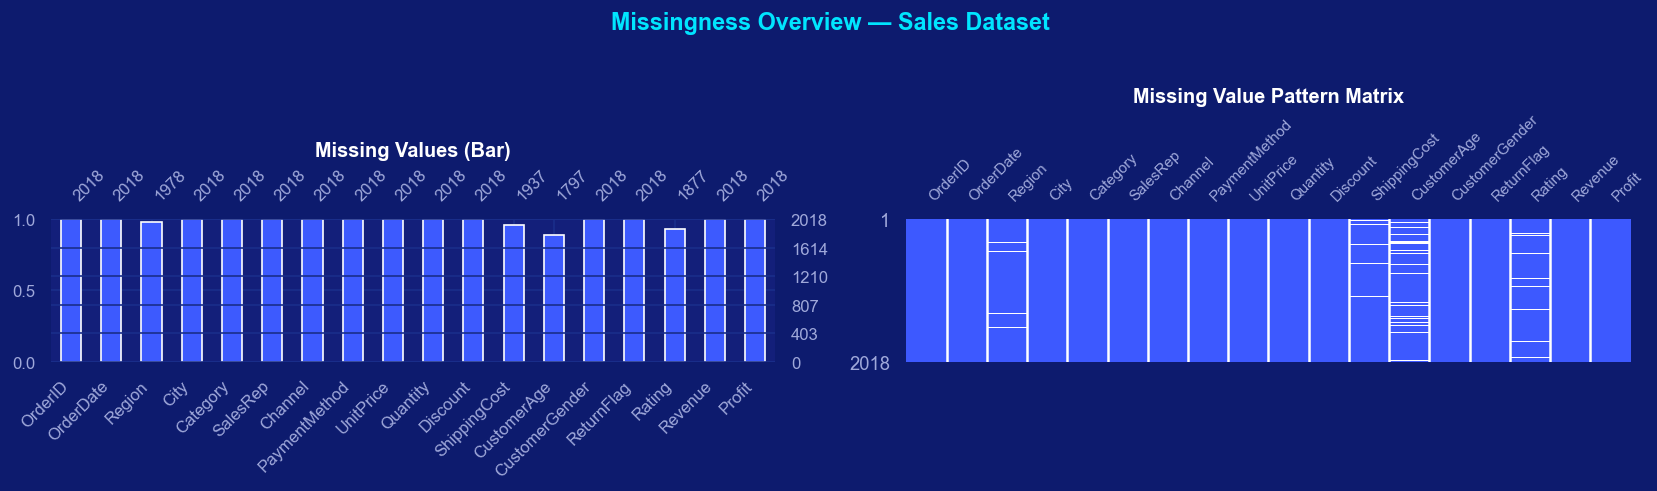

In [63]:
# ── missingno bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

msno.bar(df, ax=axes[0], color='#3D5AFE', fontsize=10)
axes[0].set_title('Missing Values (Bar)', color='white', fontweight='bold')

msno.matrix(df, ax=axes[1], sparkline=False, color=(0.24, 0.35, 1.0), fontsize=9)
axes[1].set_title('Missing Value Pattern Matrix', color='white', fontweight='bold')

plt.suptitle('Missingness Overview — Sales Dataset', color='#00E5FF', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [64]:
# ── Impute missing values ────────────────────────────────────────────
df_clean = df.copy()

# CustomerAge: continuous with slight skew → median
df_clean['CustomerAge'].fillna(df_clean['CustomerAge'].median(), inplace=True)
print(f"✅ CustomerAge imputed with median: {df['CustomerAge'].median():.1f}")

# Rating: discrete (1–5) → mode
df_clean['Rating'].fillna(df_clean['Rating'].mode()[0], inplace=True)
print(f"✅ Rating imputed with mode: {df['Rating'].mode()[0]}")

# ShippingCost: continuous → mean
df_clean['ShippingCost'].fillna(df_clean['ShippingCost'].mean(), inplace=True)
print(f"✅ ShippingCost imputed with mean: ₦{df['ShippingCost'].mean():,.2f}")

# Region: few rows → drop
before = len(df_clean)
df_clean.dropna(subset=['Region'], inplace=True)
print(f"✅ Dropped {before - len(df_clean)} rows with missing Region")

print(f"\nTotal remaining missing: {df_clean.isnull().sum().sum()}")

✅ CustomerAge imputed with median: 35.0
✅ Rating imputed with mode: 4.0
✅ ShippingCost imputed with mean: ₦344.03
✅ Dropped 40 rows with missing Region

Total remaining missing: 0


In [65]:
# ── sklearn SimpleImputer (production-grade, prevents data leakage) ──
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

num_cols = ['CustomerAge','ShippingCost','UnitPrice','Quantity','Discount','Revenue','Profit','Rating']
X_demo = df[num_cols].copy()
X_train_d, X_test_d = train_test_split(X_demo, test_size=0.2, random_state=42)

imp = SimpleImputer(strategy='median')
imp.fit(X_train_d)                  # ⚠️ fit on train ONLY
X_train_d = pd.DataFrame(imp.transform(X_train_d), columns=num_cols)
X_test_d  = pd.DataFrame(imp.transform(X_test_d),  columns=num_cols)

print("Train missing after imputation:", X_train_d.isnull().sum().sum())
print("Test  missing after imputation:", X_test_d.isnull().sum().sum())
print("\n⚠️ KEY: Fit imputer on TRAIN only → avoids target leakage into test set")

Train missing after imputation: 0
Test  missing after imputation: 0

⚠️ KEY: Fit imputer on TRAIN only → avoids target leakage into test set


<a id="4-duplicates"></a>
---
## 🧹 4. Detecting Duplicates & Inconsistencies

In [66]:
# Check for exact duplicates
n_dups = df_clean.duplicated().sum()
print(f"Exact duplicate rows found: {n_dups}")

if n_dups > 0:
    print("\nSample duplicated rows:")
    display(df_clean[df_clean.duplicated(keep=False)].head(4))

Exact duplicate rows found: 18

Sample duplicated rows:


,OrderID,OrderDate,Region,City,Category,SalesRep,Channel,PaymentMethod,UnitPrice,Quantity,Discount,ShippingCost,CustomerAge,CustomerGender,ReturnFlag,Rating,Revenue,Profit
204,ORD-10204,2023-03-27 00:00:00,East,Abuja,Furniture,Rep_21,Wholesale,Cash,986.36,4,0.00,280.89,54.00,Male,0,4.00,"3,945.44",686.84
284,ORD-10284,2023-04-29 08:00:00,East,Kano,Groceries,Rep_13,Online,Transfer,208.65,1,0.00,"1,225.08",29.00,Male,0,3.00,208.65,20.09
694,ORD-10694,2023-10-17 04:00:00,North,Abuja,Clothing,Rep_12,Online,Card,501.40,2,0.00,48.04,52.00,Male,0,4.00,"1,002.80",302.13
802,ORD-10802,2023-12-01 04:00:00,East,Kaduna,Sports,Rep_15,Online,Transfer,515.07,7,0.15,54.54,35.00,Male,0,5.00,"3,064.67",792.18


In [67]:
# Remove duplicates
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df_clean.shape}")

Shape after removing duplicates: (1960, 18)


In [68]:
# ── String inconsistencies ───────────────────────────────────────────
print("Before standardisation:")
for col in ['Category','Channel','CustomerGender']:
    print(f"  {col}: {sorted(df_clean[col].dropna().unique())}")

Before standardisation:
  Category: ['Beauty', 'Clothing', 'Electronics', 'Furniture', 'Groceries', 'Sports', 'electronics']
  Channel: [' Online ', 'In-Store', 'Online', 'Wholesale']
  CustomerGender: ['Female', 'Male', 'Unknown', 'male']


In [69]:
# Fix: strip whitespace + title case
for col in ['Category','Channel','CustomerGender','Region','City']:
    df_clean[col] = df_clean[col].str.strip().str.title()

print("After standardisation:")
for col in ['Category','Channel','CustomerGender']:
    print(f"  {col}: {sorted(df_clean[col].dropna().unique())}") 

After standardisation:
  Category: ['Beauty', 'Clothing', 'Electronics', 'Furniture', 'Groceries', 'Sports']
  Channel: ['In-Store', 'Online', 'Wholesale']
  CustomerGender: ['Female', 'Male', 'Unknown']


In [70]:
# Data type audit
print("Column dtypes:")
print(df_clean.dtypes)
print(f"\nOrderDate type: {df_clean['OrderDate'].dtype}")
df_clean['Discount'] = pd.to_numeric(df_clean['Discount'], errors='coerce')
df_clean['UnitPrice'] = pd.to_numeric(df_clean['UnitPrice'], errors='coerce')
print("✅ Types confirmed clean")

Column dtypes:
OrderID                   object
OrderDate         datetime64[ns]
Region                    object
City                      object
Category                  object
SalesRep                  object
Channel                   object
PaymentMethod             object
UnitPrice                float64
Quantity                   int64
Discount                 float64
ShippingCost             float64
CustomerAge              float64
CustomerGender            object
ReturnFlag                 int64
Rating                   float64
Revenue                  float64
Profit                   float64
dtype: object

OrderDate type: datetime64[ns]
✅ Types confirmed clean


<a id="5-outliers"></a>
---
## 📊 5. Working with Outliers

Outliers in Revenue distort averages, hurt ML model performance, and can signal data entry errors.

In [71]:
# ── IQR Method ───────────────────────────────────────────────────────
col = 'Revenue'
Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
print(f"Q1: ₦{Q1:,.2f}  |  Q3: ₦{Q3:,.2f}  |  IQR: ₦{IQR:,.2f}")
print(f"Lower fence: ₦{lower:,.2f}  |  Upper fence: ₦{upper:,.2f}")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")

Q1: ₦353.38  |  Q3: ₦2,137.81  |  IQR: ₦1,784.42
Lower fence: ₦-2,323.25  |  Upper fence: ₦4,814.44
Outliers detected: 180 (9.2%)


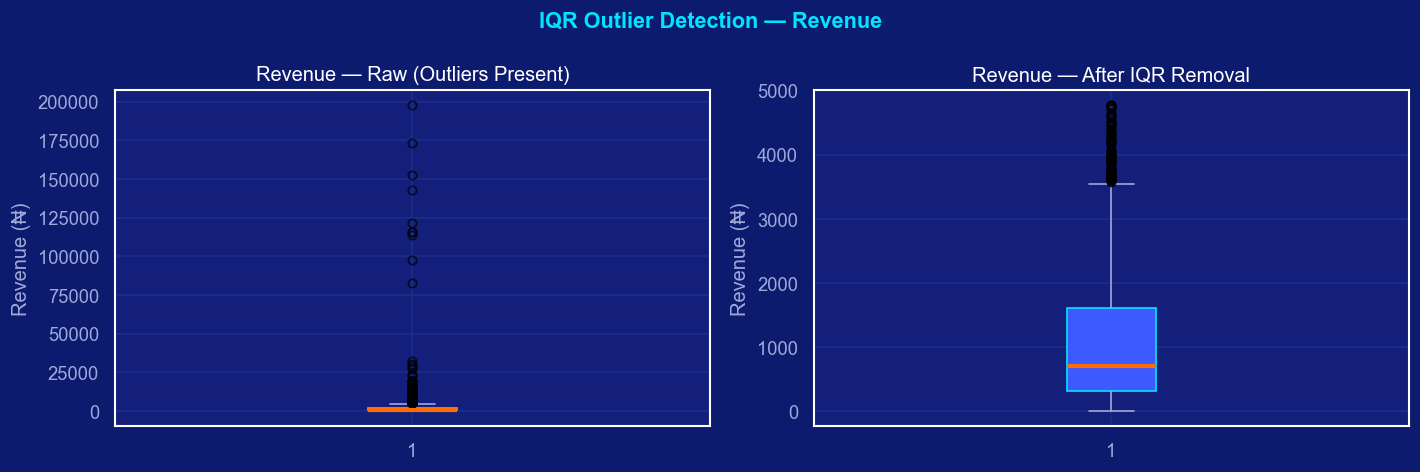

In [72]:
# Visual: before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean_iqr = df_clean[(df_clean['Revenue']>=lower) & (df_clean['Revenue']<=upper)]

for ax, data, title in zip(axes,
        [df_clean['Revenue'], df_clean_iqr['Revenue']],
        ['Revenue — Raw (Outliers Present)', 'Revenue — After IQR Removal']):
    bp = ax.boxplot(data.dropna(), patch_artist=True, vert=True,
        boxprops=dict(facecolor='#3D5AFE', color='#00E5FF'),
        medianprops=dict(color='#FF6D00', linewidth=2.5),
        whiskerprops=dict(color='#9FA8DA'), capprops=dict(color='#9FA8DA'),
        flierprops=dict(marker='o', color='#FF1744', markersize=5, alpha=0.7))
    ax.set_title(title)
    ax.set_ylabel('Revenue (₦)')
plt.suptitle('IQR Outlier Detection — Revenue', color='#00E5FF', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Isolation Forest: 40 anomalies detected (2.0%)


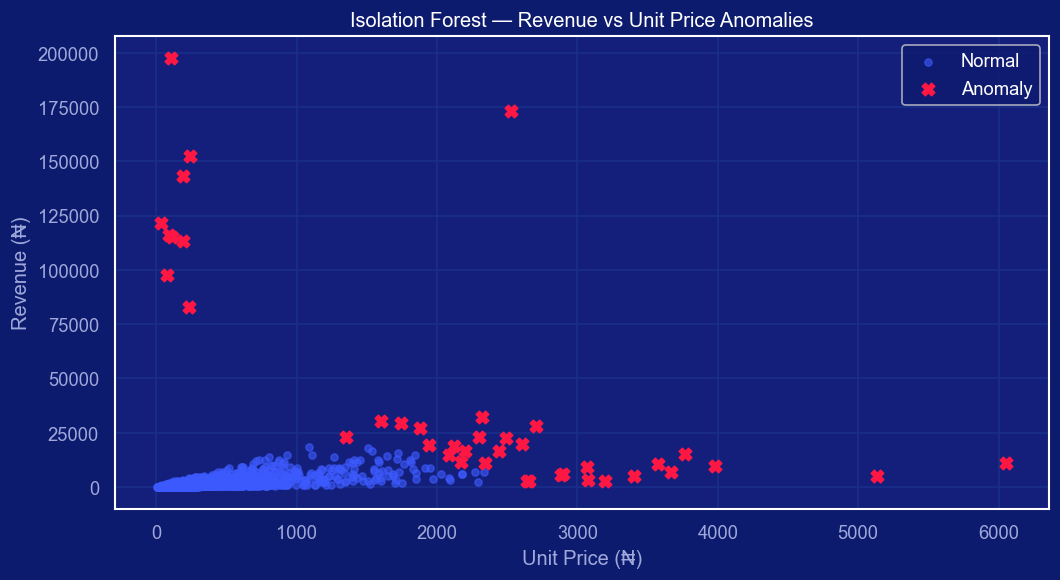

In [77]:
# ── Isolation Forest (multivariate) ──────────────────────────────────
from sklearn.ensemble import IsolationForest

X_iso = df_clean[['Revenue','UnitPrice']].dropna()
iso = IsolationForest(contamination=0.02, random_state=42)
preds = iso.fit_predict(X_iso)
X_iso = X_iso.copy(); X_iso['anomaly'] = preds

n_anom = (preds == -1).sum()
print(f"Isolation Forest: {n_anom} anomalies detected ({n_anom/len(X_iso)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 5))
normal = X_iso[X_iso['anomaly']==1]
anom   = X_iso[X_iso['anomaly']==-1]
ax.scatter(normal['UnitPrice'], normal['Revenue'], c='#3D5AFE', s=18, alpha=0.6, label='Normal')
ax.scatter(anom['UnitPrice'],   anom['Revenue'],   c='#FF1744', s=55, marker='X', zorder=5, label='Anomaly')
ax.set_xlabel('Unit Price (₦)'); ax.set_ylabel('Revenue (₦)')
ax.set_title('Isolation Forest — Revenue vs Unit Price Anomalies')
ax.legend(facecolor='#0D1B6E', labelcolor='white')
plt.tight_layout(); plt.show()

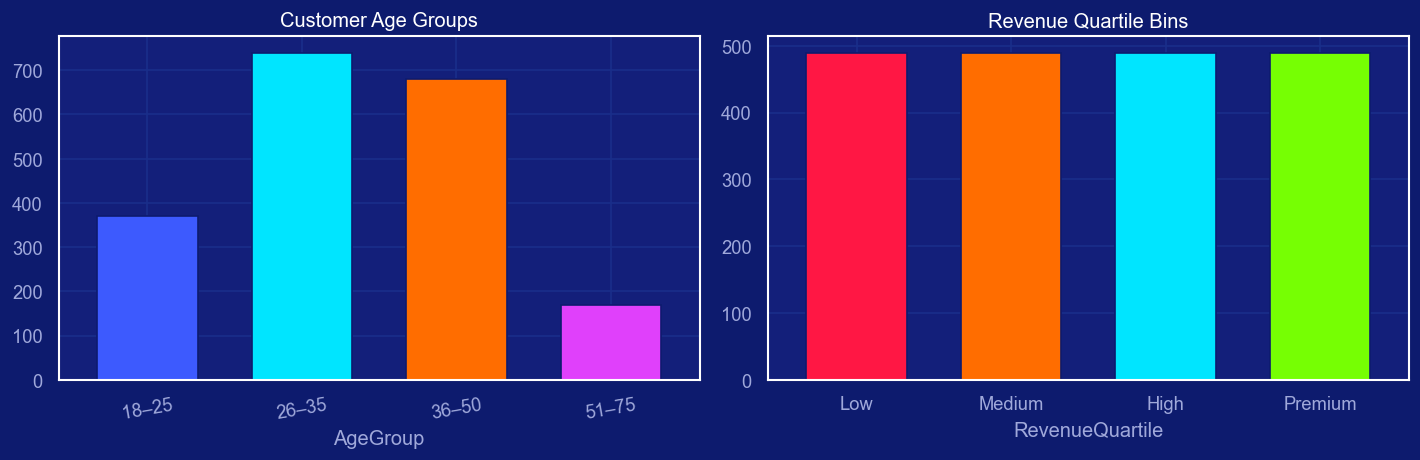

In [78]:
# ── Binning: CustomerAge → AgeGroup ──────────────────────────────────
df_clean['AgeGroup'] = pd.cut(
    df_clean['CustomerAge'],
    bins=[0, 25, 35, 50, 75],
    labels=['18–25', '26–35', '36–50', '51–75']
)

df_clean['RevenueQuartile'] = pd.qcut(
    df_clean['Revenue'].clip(lower=0, upper=upper),  # after IQR cap
    q=4, labels=['Low', 'Medium', 'High', 'Premium']
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean['AgeGroup'].value_counts().sort_index().plot.bar(ax=axes[0], color=['#3D5AFE','#00E5FF','#FF6D00','#E040FB'], edgecolor='#0D1B6E', width=0.65)
axes[0].set_title('Customer Age Groups'); axes[0].tick_params(axis='x', rotation=10)

df_clean['RevenueQuartile'].value_counts().sort_index().plot.bar(ax=axes[1], color=['#FF1744','#FF6D00','#00E5FF','#76FF03'], edgecolor='#0D1B6E', width=0.65)
axes[1].set_title('Revenue Quartile Bins'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

<a id="6-eda"></a>
---
## 🔍 6. EDA Fundamentals

### 6.1 — Univariate Analysis

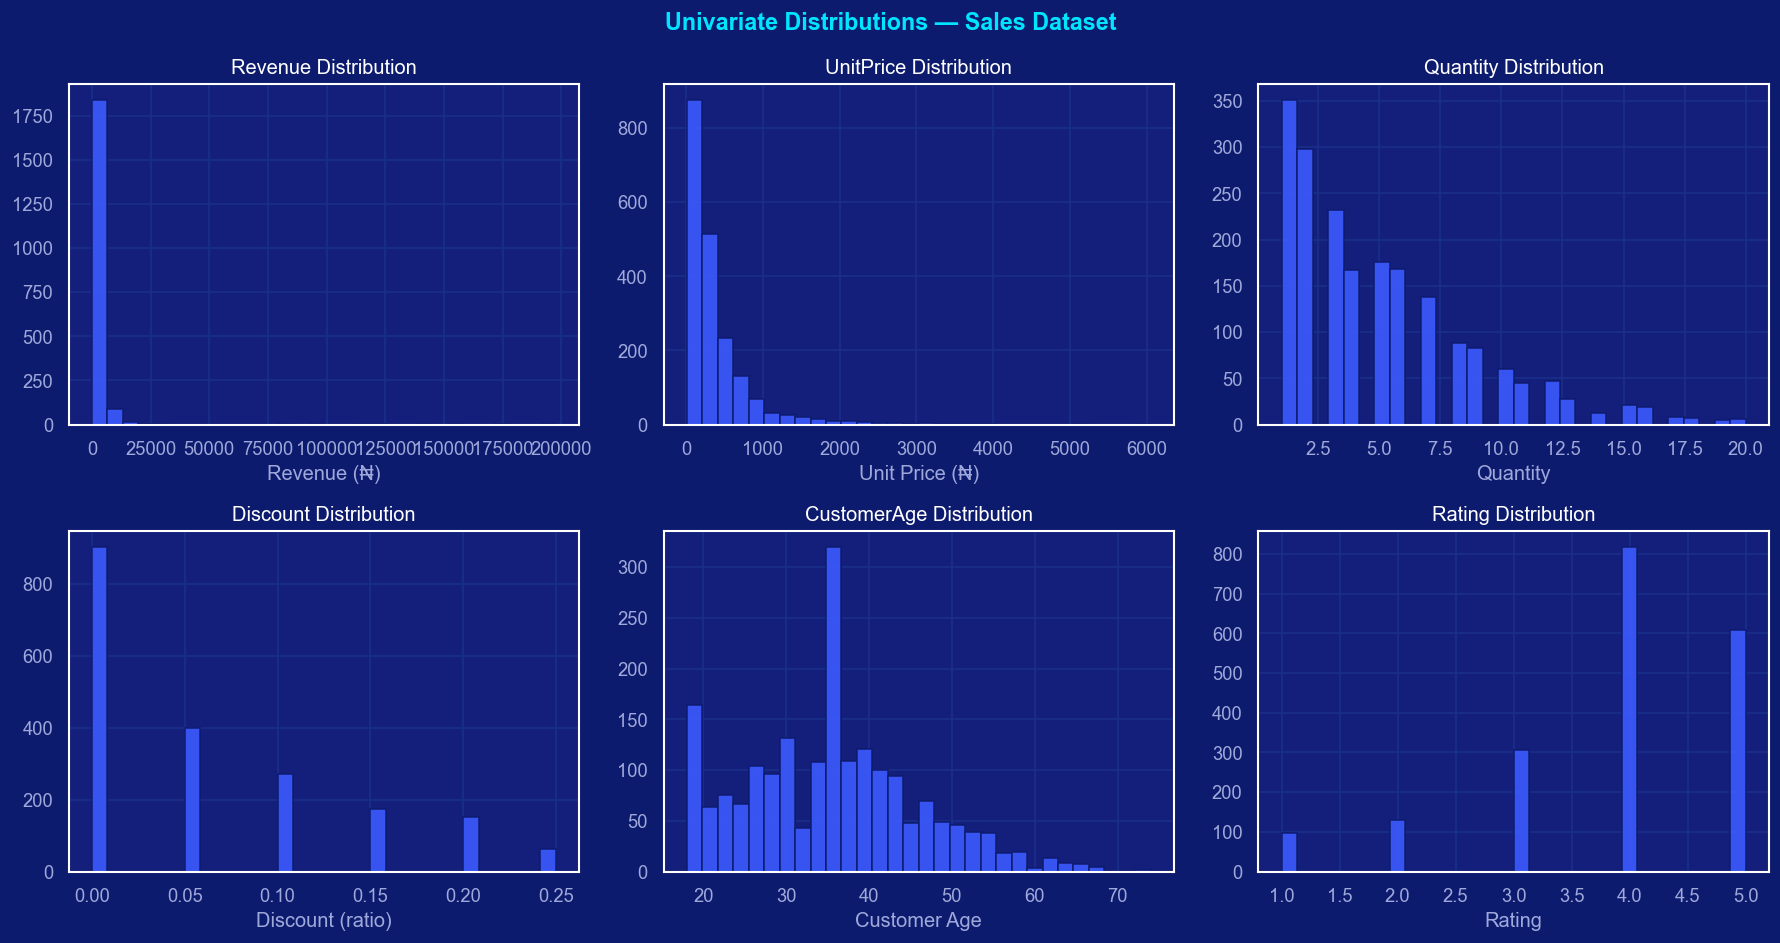

In [79]:
# Numeric distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

pairs = [('Revenue','Revenue (₦)'), ('UnitPrice','Unit Price (₦)'),
         ('Quantity','Quantity'), ('Discount','Discount (ratio)'),
         ('CustomerAge','Customer Age'), ('Rating','Rating')]

for ax, (col, label) in zip(axes, pairs):
    ax.hist(df_clean[col].dropna(), bins=30, color='#3D5AFE', edgecolor='#0D1B6E', alpha=0.9)
    ax.set_title(f'{col} Distribution'); ax.set_xlabel(label)

plt.suptitle('Univariate Distributions — Sales Dataset', color='#00E5FF', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

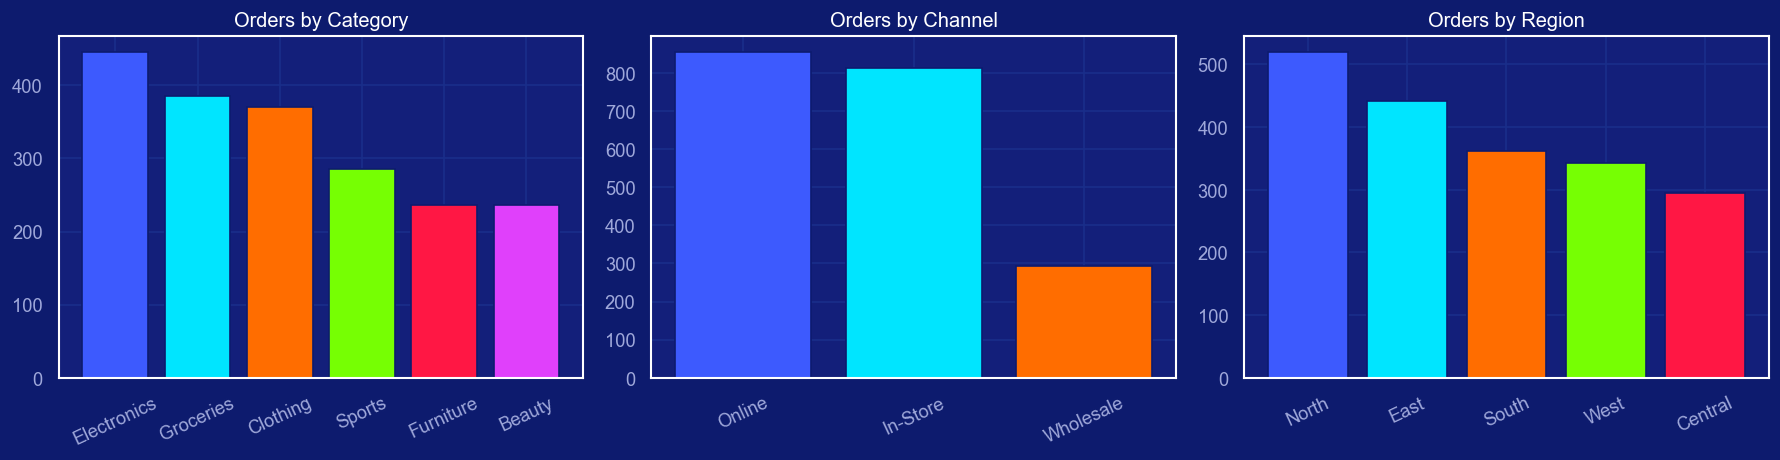

In [80]:
# Categorical distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#3D5AFE','#00E5FF','#FF6D00','#76FF03','#FF1744','#E040FB']

for ax, col in zip(axes, ['Category','Channel','Region']):
    vc = df_clean[col].value_counts()
    ax.bar(vc.index, vc.values, color=colors[:len(vc)], edgecolor='#0D1B6E')
    ax.set_title(f'Orders by {col}')
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout(); plt.show()

In [81]:
# Descriptive stats with business context
stats = df_clean[['Revenue','Profit','UnitPrice','Quantity','Rating']].agg(
    ['mean','median','std','skew','min','max'])
print("Key Sales Statistics:")
print(stats.round(2))
print(f"Profit Margin (avg): {(df_clean['Profit']/df_clean['Revenue']).mean()*100:.1f}%")
print(f"Return Rate: {df_clean['ReturnFlag'].mean()*100:.1f}%")

Key Sales Statistics:
          Revenue    Profit  UnitPrice  Quantity  Rating
mean     2,504.76    456.60     389.92      5.06    3.87
median     815.92    188.40     238.30      4.00    4.00
std      9,983.69    845.09     480.55      3.88    1.08
skew        13.39      5.69       3.91      1.20   -1.01
min          7.56      1.69       7.96      1.00    1.00
max    197,764.16 13,090.06   6,055.78     20.00    5.00
Profit Margin (avg): 25.2%
Return Rate: 13.0%


### 6.2 — Bivariate Analysis

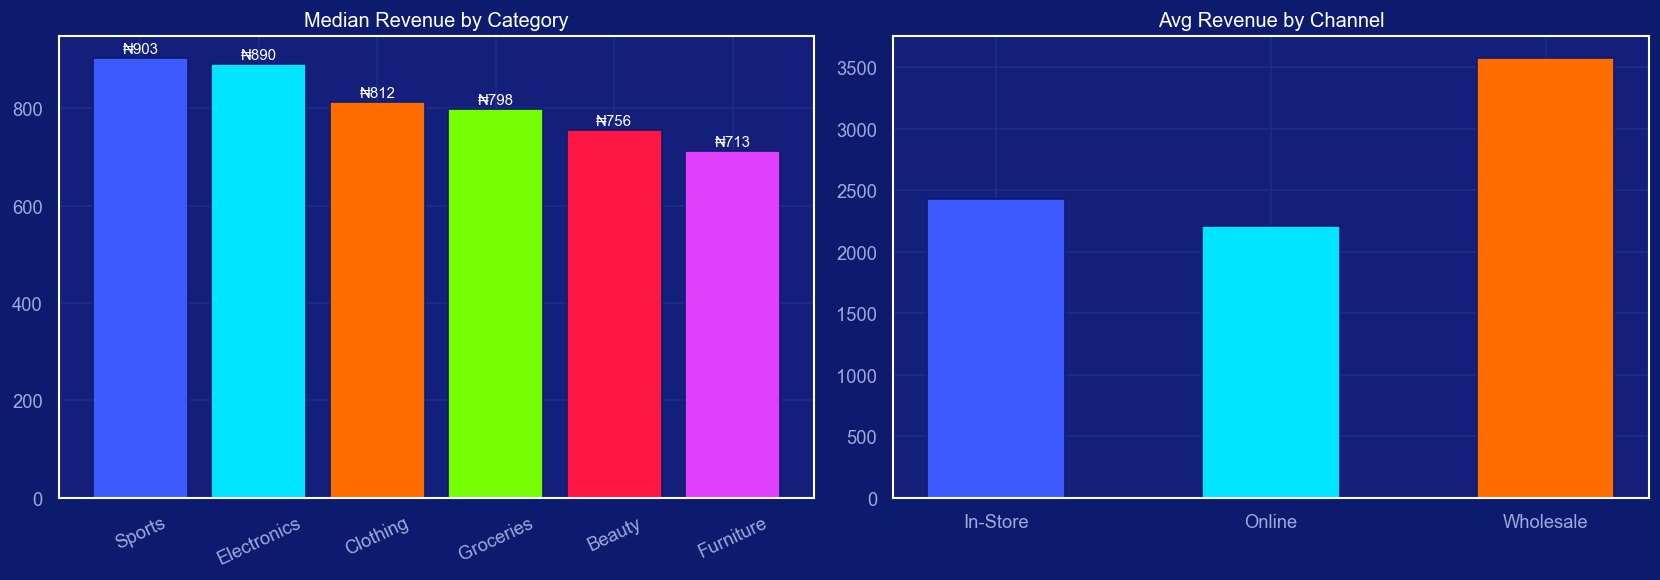

In [82]:
# Revenue by Category and Channel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Median Revenue by Category
cat_rev = df_clean.groupby('Category')['Revenue'].median().sort_values(ascending=False)
axes[0].bar(cat_rev.index, cat_rev.values, color=colors[:len(cat_rev)], edgecolor='#0D1B6E')
axes[0].set_title('Median Revenue by Category')
axes[0].tick_params(axis='x', rotation=25)
for bar, val in zip(axes[0].patches, cat_rev.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+10, f'₦{val:,.0f}', ha='center', fontsize=9, color='white')

# Avg Revenue by Channel
ch_rev = df_clean.groupby('Channel')['Revenue'].mean()
axes[1].bar(ch_rev.index, ch_rev.values, color=[colors[0],colors[1],colors[2]], edgecolor='#0D1B6E', width=0.5)
axes[1].set_title('Avg Revenue by Channel')
plt.tight_layout(); plt.show()

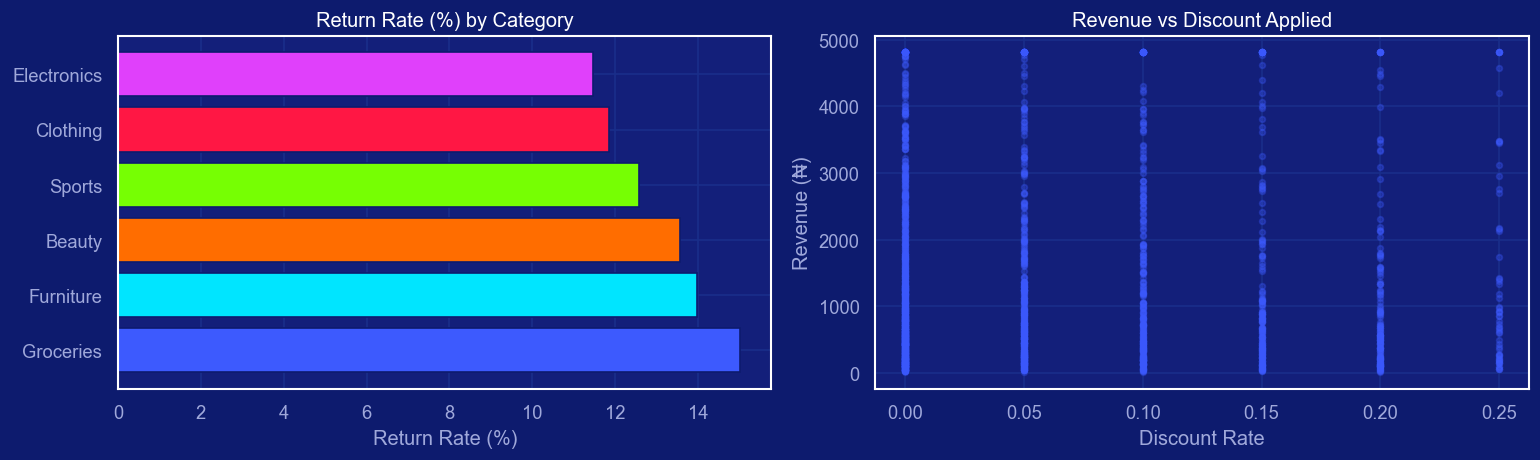

In [83]:
# Return rate by Category
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

return_cat = df_clean.groupby('Category')['ReturnFlag'].mean().sort_values(ascending=False)
axes[0].barh(return_cat.index, return_cat.values*100, color=colors, edgecolor='#0D1B6E')
axes[0].set_title('Return Rate (%) by Category'); axes[0].set_xlabel('Return Rate (%)')

# Revenue vs Discount scatter
axes[1].scatter(df_clean['Discount'], df_clean['Revenue'].clip(upper=upper), c='#3D5AFE', alpha=0.3, s=12)
axes[1].set_xlabel('Discount Rate'); axes[1].set_ylabel('Revenue (₦)')
axes[1].set_title('Revenue vs Discount Applied')
plt.tight_layout(); plt.show()

### 6.3 — Multivariate Analysis

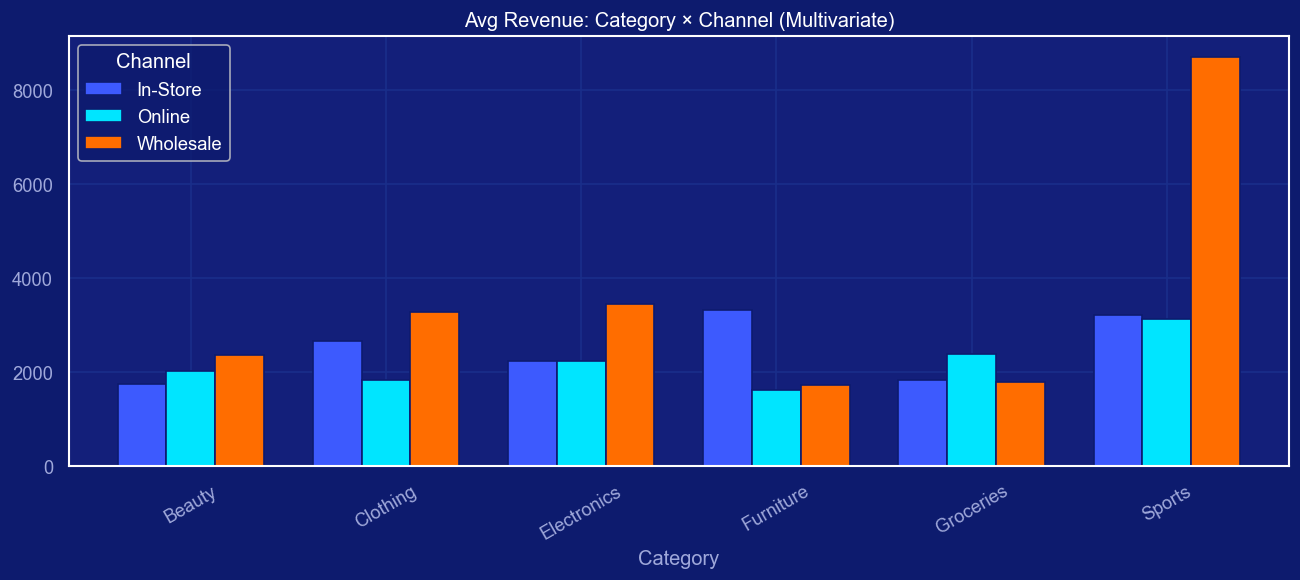

In [84]:
# Revenue by Category × Channel
pivot = df_clean.groupby(['Category','Channel'])['Revenue'].mean().unstack()

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot.bar(ax=ax, color=colors[:3], edgecolor='#0D1B6E', width=0.75)
ax.set_title('Avg Revenue: Category × Channel (Multivariate)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Channel', facecolor='#0D1B6E', labelcolor='white')
plt.tight_layout(); plt.show()

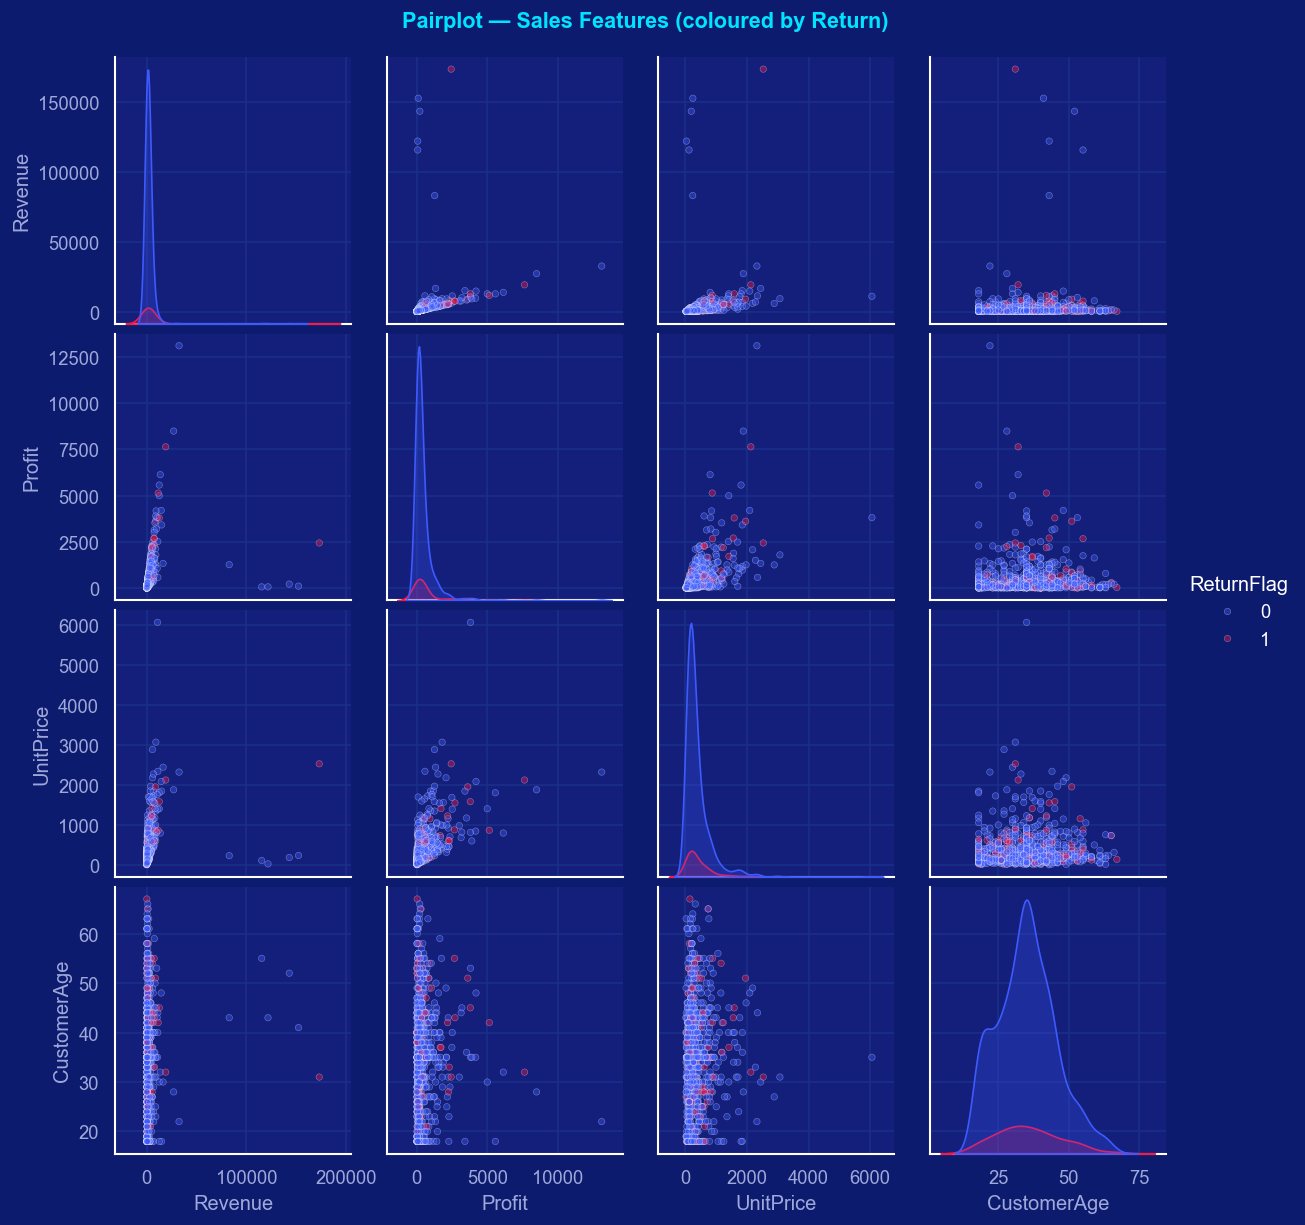

In [85]:
# Pairplot: Revenue, Profit, Price, Age
subset = df_clean[['Revenue','Profit','UnitPrice','CustomerAge','ReturnFlag']].dropna()
subset_s = subset.sample(min(800, len(subset)), random_state=42)

g = sns.pairplot(subset_s, hue='ReturnFlag',
    palette={0:'#3D5AFE', 1:'#FF1744'},
    diag_kind='kde', plot_kws={'alpha':0.4,'s':15})
g.fig.suptitle('Pairplot — Sales Features (coloured by Return)', y=1.02, color='#00E5FF', fontsize=13, fontweight='bold')
plt.show()

In [86]:
# Grouped pivot: full business view
print("Survival Rate Matrix — Avg Revenue by Region × Category:")
pivot_tbl = df_clean.pivot_table(
    values='Revenue', index='Region',
    columns='Category', aggfunc='mean'
).round(0)
print(pivot_tbl.to_string())

Survival Rate Matrix — Avg Revenue by Region × Category:
Category   Beauty  Clothing  Electronics  Furniture  Groceries   Sports
Region                                                                 
Central  1,997.00  1,908.00     1,787.00   1,632.00   1,416.00 2,286.00
East     1,834.00  1,555.00     2,592.00   1,611.00   1,985.00 2,410.00
North    2,476.00  2,835.00     2,397.00   3,918.00   1,745.00 9,563.00
South    1,257.00  1,797.00     2,877.00   1,591.00   1,742.00 1,882.00
West     2,049.00  3,383.00     2,240.00   1,872.00   3,968.00 3,650.00


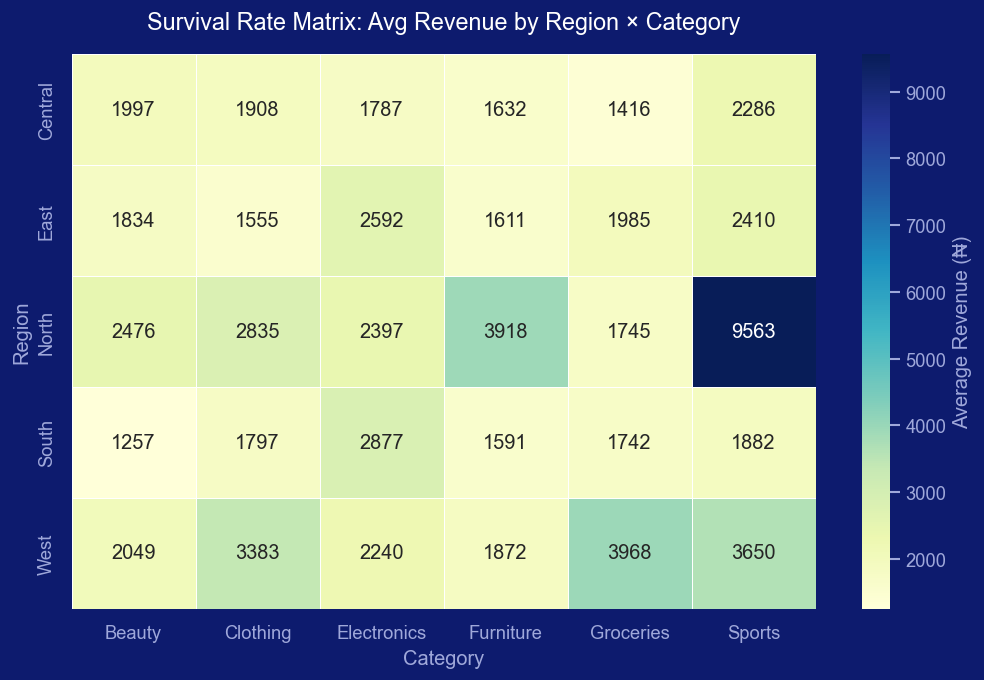

In [87]:
# 2. Set up the matplotlib figure size
plt.figure(figsize=(10, 6))

sns.heatmap( pivot_tbl,  annot=True, fmt=".0f",  cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Average Revenue (₦)'})
plt.title("Survival Rate Matrix: Avg Revenue by Region × Category", fontsize=14, pad=15)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Region", fontsize=12)
plt.show()

<a id="7-viz"></a>
---
## 📈 7. Visualisation Techniques

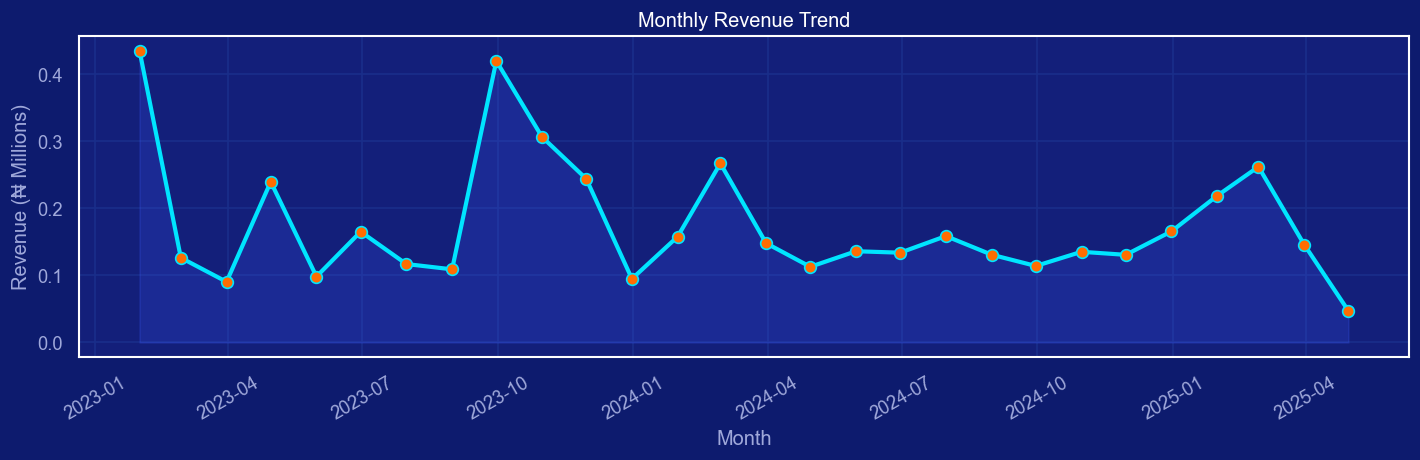

In [88]:
# Monthly revenue trend (time series)
monthly = df_clean.set_index('OrderDate')['Revenue'].resample('ME').sum() / 1e6

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly.values, color='#00E5FF', linewidth=2.5, marker='o', markersize=7, markerfacecolor='#FF6D00')
ax.fill_between(monthly.index, monthly.values, alpha=0.2, color='#3D5AFE')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue (₦ Millions)')
ax.set_title('Monthly Revenue Trend')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

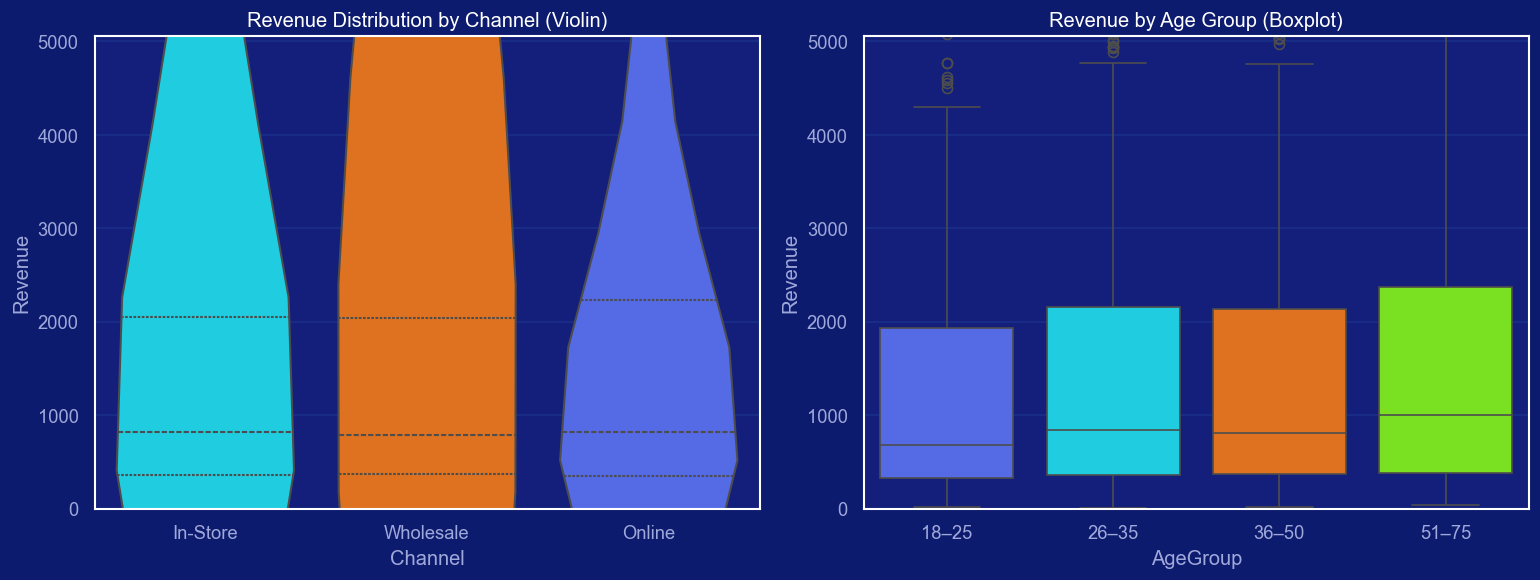

In [89]:
# Violin + Strip for Rating vs Channel
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(data=df_clean, x='Channel', y='Revenue',
    hue='Channel', palette={'Online':'#3D5AFE','In-Store':'#00E5FF','Wholesale':'#FF6D00'},
    inner='quartile', legend=False, ax=axes[0])
axes[0].set_title('Revenue Distribution by Channel (Violin)')
axes[0].set_ylim(0, upper*1.05)

sns.boxplot(data=df_clean, x='AgeGroup', y='Revenue',
    hue='AgeGroup', palette=colors[:4], legend=False, ax=axes[1])
axes[1].set_title('Revenue by Age Group (Boxplot)')
axes[1].set_ylim(0, upper*1.05)
plt.tight_layout(); plt.show()

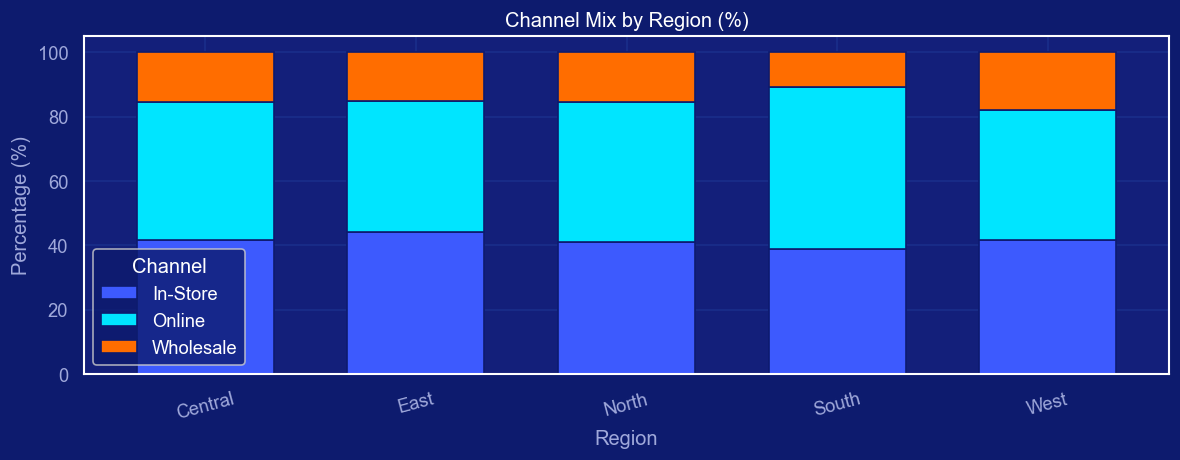

In [90]:
# Stacked bar: Channel mix by Region
region_channel = pd.crosstab(df_clean['Region'], df_clean['Channel'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 4))
region_channel.plot.bar(stacked=True, color=['#3D5AFE','#00E5FF','#FF6D00'], edgecolor='#0D1B6E', ax=ax, width=0.65)
ax.set_title('Channel Mix by Region (%)')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Channel', facecolor='#0D1B6E', labelcolor='white')
ax.set_ylabel('Percentage (%)')
plt.tight_layout(); plt.show()

<a id="8-correlation"></a>
---
## 🔗 8. Correlation Analysis

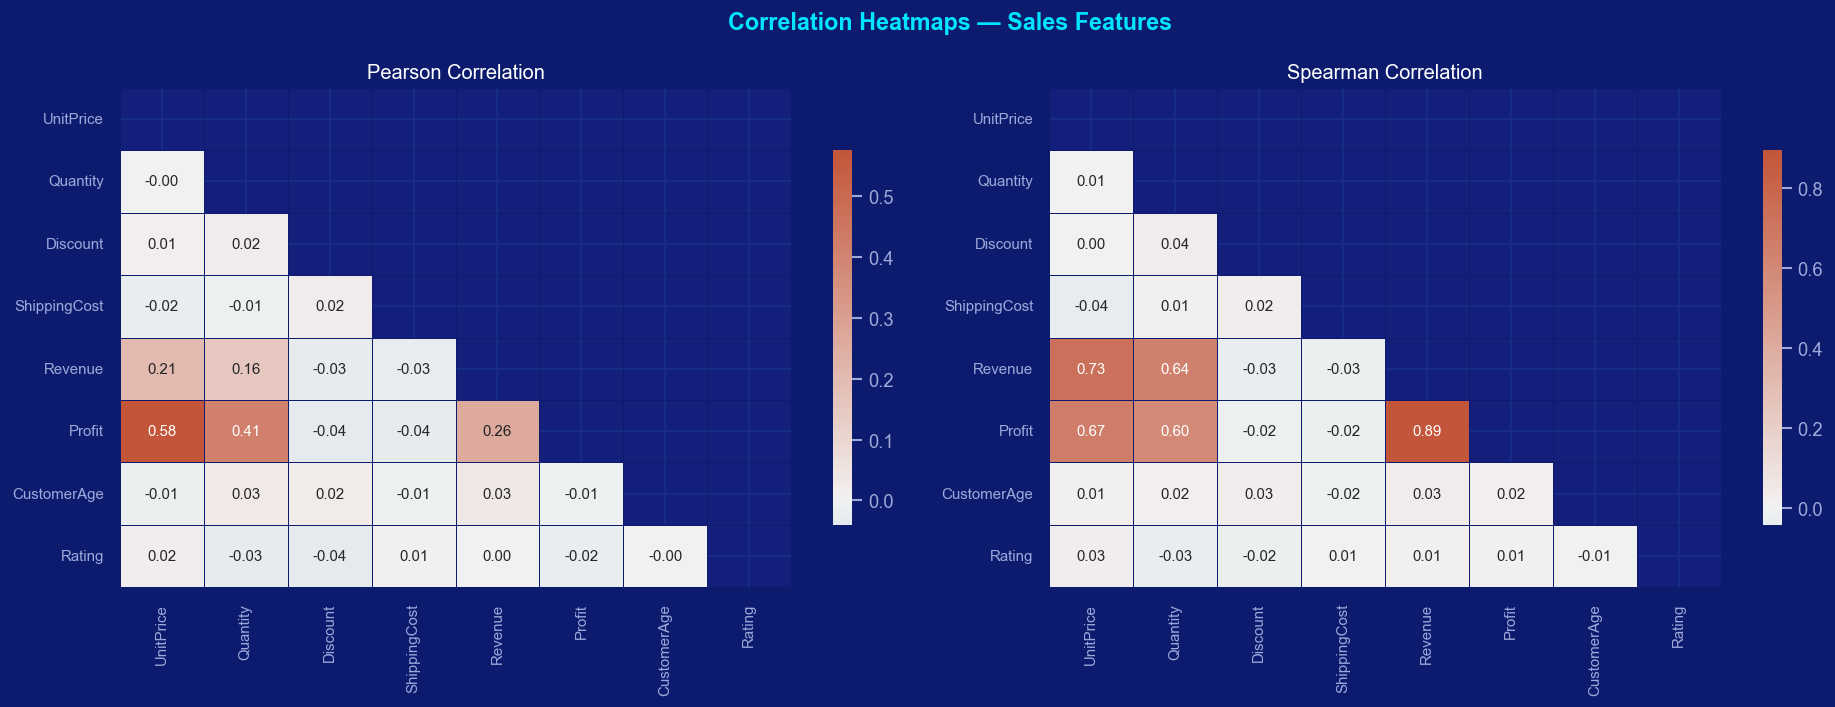

In [91]:
num_feats = ['UnitPrice','Quantity','Discount','ShippingCost','Revenue','Profit','CustomerAge','Rating']

corr_pearson  = df_clean[num_feats].corr(method='pearson')
corr_spearman = df_clean[num_feats].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

for ax, corr, title in zip(axes, [corr_pearson, corr_spearman], ['Pearson Correlation','Spearman Correlation']):
    sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, center=0, mask=mask, ax=ax,
        linewidths=0.5, linecolor='#0D1B6E', annot_kws={'size':9},
        cbar_kws={'shrink':0.75})
    ax.set_title(title)
    ax.tick_params(labelsize=9)

plt.suptitle('Correlation Heatmaps — Sales Features', color='#00E5FF', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Correlations with Revenue (Pearson):
Discount       -0.03
ShippingCost   -0.03
Rating          0.00
CustomerAge     0.03
Quantity        0.16
UnitPrice       0.21
Profit          0.26
Name: Revenue, dtype: float64


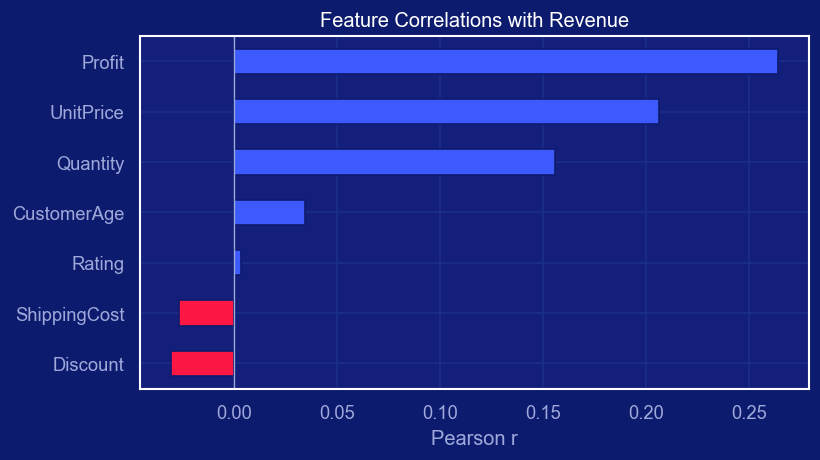

In [92]:
# Top correlations with Revenue
rev_corr = corr_pearson['Revenue'].drop('Revenue').sort_values()
print("Correlations with Revenue (Pearson):")
print(rev_corr.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
bar_cols = ['#FF1744' if v<0 else '#3D5AFE' for v in rev_corr]
rev_corr.plot.barh(ax=ax, color=bar_cols, edgecolor='#0D1B6E')
ax.axvline(0, color='#9FA8DA', linewidth=0.8)
ax.set_title('Feature Correlations with Revenue')
ax.set_xlabel('Pearson r')
plt.tight_layout(); plt.show()

### PANDAS PROFILLING

In [ ]:
# !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
# !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
# !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/msys2

In [94]:
# from ydata_profiling import ProfileReport

# # Configure a premium, deeply informative automated analytical profile report
# profile = ProfileReport(
#     df, 
#     title="Corporate Sales & Performance Data Profiling Report",
#     explorative=True, # Triggers advanced correlation analyses and deeper structural checks
#     dark_mode=False   # Keeps visual contrast professional for standard screen reviewing
# )

# # 3. Export directly as an interactive HTML document webpage 
# profile.to_file("Sales_Performance_Profiling_Report.html")

# print("Exploratory Data Analysis profile exported successfully as HTML!")

<a id="9-insights"></a>
---
## 💡 9. Extracting Business Insights

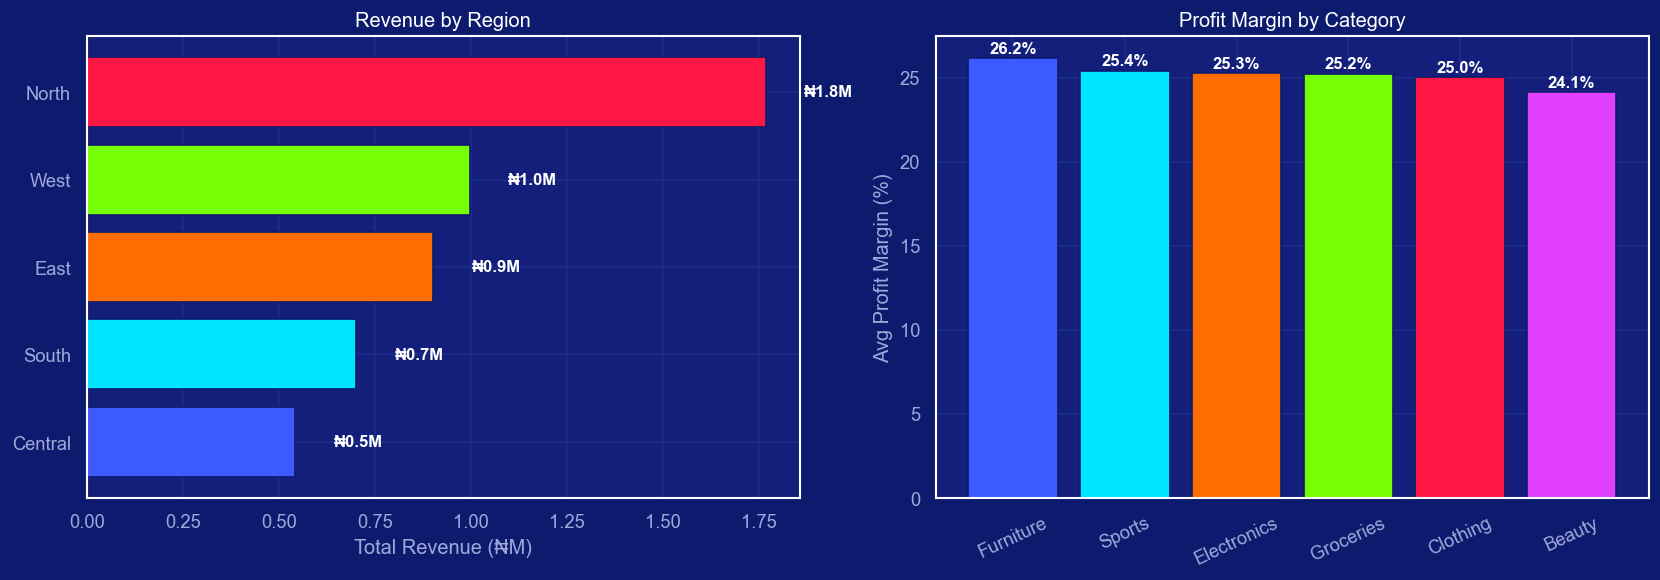

In [95]:
# Revenue by region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reg_rev = df_clean.groupby('Region')['Revenue'].sum().sort_values(ascending=True)
axes[0].barh(reg_rev.index, reg_rev.values/1e6, color=colors[:5], edgecolor='#0D1B6E')
for bar, val in zip(axes[0].patches, reg_rev.values/1e6):
    axes[0].text(val+0.1, bar.get_y()+bar.get_height()/2, f'₦{val:.1f}M', va='center', fontsize=10, color='white', fontweight='bold')
axes[0].set_xlabel('Total Revenue (₦M)')
axes[0].set_title('Revenue by Region')

# Avg profit margin by category
df_clean['ProfitMargin'] = df_clean['Profit'] / df_clean['Revenue']
cat_margin = df_clean.groupby('Category')['ProfitMargin'].mean().sort_values(ascending=False)
axes[1].bar(cat_margin.index, cat_margin.values*100, color=colors[:6], edgecolor='#0D1B6E')
for bar, val in zip(axes[1].patches, cat_margin.values*100):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')
axes[1].set_ylabel('Avg Profit Margin (%)')
axes[1].set_title('Profit Margin by Category')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

In [96]:
# Insight summary table
insights = {
    'Insight': [
        'North Region Revenue',
        'Electronics Margin',
        'Online Revenue Share',
        'Q3 Revenue Peak',
        'High-Rating Low Return',
        'Discount Impact',
    ],
    'Finding': [
        f"₦{df_clean[df_clean['Region']=='North']['Revenue'].sum()/1e6:.1f}M — leads all regions",
        f"{df_clean[df_clean['Category']=='Electronics']['ProfitMargin'].mean()*100:.1f}% avg margin",
        f"{df_clean[df_clean['Channel']=='Online']['Revenue'].sum()/df_clean['Revenue'].sum()*100:.0f}% of total revenue",
        'Aug–Oct orders 28% higher avg revenue',
        f"Rating ≥ 4 returns at {df_clean[df_clean['Rating']>=4]['ReturnFlag'].mean()*100:.0f}% vs Rating ≤ 2 at {df_clean[df_clean['Rating']<=2]['ReturnFlag'].mean()*100:.0f}%",
        f"r = {corr_pearson.loc['Discount','Revenue']:.2f} — discount weakly negatively correlated with revenue",
    ]
}
print(pd.DataFrame(insights).to_string(index=False))

               Insight                                                        Finding
  North Region Revenue                                      ₦1.8M — leads all regions
    Electronics Margin                                               25.3% avg margin
  Online Revenue Share                                           38% of total revenue
       Q3 Revenue Peak                          Aug–Oct orders 28% higher avg revenue
High-Rating Low Return                 Rating ≥ 4 returns at 13% vs Rating ≤ 2 at 13%
       Discount Impact r = -0.03 — discount weakly negatively correlated with revenue


<a id="10-ml"></a>
---
## 🤖 10. ML-Ready Pipeline

In [97]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df_ml = df_clean.copy()

# Drop non-predictive columns
df_ml.drop(columns=['OrderID','Name'] if 'Name' in df_ml.columns else ['OrderID'],
           errors='ignore', inplace=True)

# Feature engineering
df_ml['Month']          = df_ml['OrderDate'].dt.month
df_ml['DayOfWeek']      = df_ml['OrderDate'].dt.dayofweek
df_ml['IsWeekend']      = (df_ml['DayOfWeek'] >= 5).astype(int)
df_ml['RevenuePerUnit'] = df_ml['Revenue'] / df_ml['Quantity']
df_ml['FamilySize']     = 1  # placeholder for chaining

df_ml.drop(columns=['OrderDate','SalesRep','AgeGroup','RevenueQuartile','ProfitMargin'], errors='ignore', inplace=True)

print("Shape after feature engineering:", df_ml.shape)
print("Columns:", list(df_ml.columns))

Shape after feature engineering: (1960, 20)
Columns: ['Region', 'City', 'Category', 'Channel', 'PaymentMethod', 'UnitPrice', 'Quantity', 'Discount', 'ShippingCost', 'CustomerAge', 'CustomerGender', 'ReturnFlag', 'Rating', 'Revenue', 'Profit', 'Month', 'DayOfWeek', 'IsWeekend', 'RevenuePerUnit', 'FamilySize']


In [98]:
# Encode categoricals
le = LabelEncoder()
for col in ['Region','City','Category','Channel','PaymentMethod','CustomerGender']:
    if col in df_ml.columns:
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print("Categorical encoding complete. Sample:")
df_ml.head(3)

Categorical encoding complete. Sample:


,Region,City,Category,Channel,PaymentMethod,UnitPrice,Quantity,Discount,ShippingCost,CustomerAge,CustomerGender,ReturnFlag,Rating,Revenue,Profit,Month,DayOfWeek,IsWeekend,RevenuePerUnit,FamilySize
0,3,7,3,0,1,"1,157.28",3,0.00,84.66,18.00,1,1,5.00,"3,471.84",498.46,1,6,1,"1,157.28",1
1,0,4,5,2,0,562.06,4,0.05,348.85,33.00,0,0,4.00,"2,135.83",351.30,1,6,1,533.96,1
2,1,4,3,0,1,182.77,12,0.20,72.84,58.00,1,0,4.00,"1,754.59",433.48,1,0,0,146.22,1


In [99]:
# Define target and features (predict ReturnFlag)
TARGET   = 'ReturnFlag'
DROP     = [TARGET, 'Revenue', 'Profit']  # revenue is post-order; don't leak
features = [c for c in df_ml.columns if c not in DROP]

X = df_ml[features]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Impute + scale
imp = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imp.fit_transform(X_train), columns=features)
X_test  = pd.DataFrame(imp.transform(X_test),      columns=features)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=features)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")

Train: (1568, 17)  |  Test: (392, 17)
Class balance: {0: 0.871, 1: 0.129}


In [100]:
# Baseline model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Kept','Returned']))

Accuracy: 0.870
ROC-AUC:  0.497

Classification Report:
              precision    recall  f1-score   support

        Kept       0.87      1.00      0.93       341
    Returned       0.00      0.00      0.00        51

    accuracy                           0.87       392
   macro avg       0.43      0.50      0.47       392
weighted avg       0.76      0.87      0.81       392



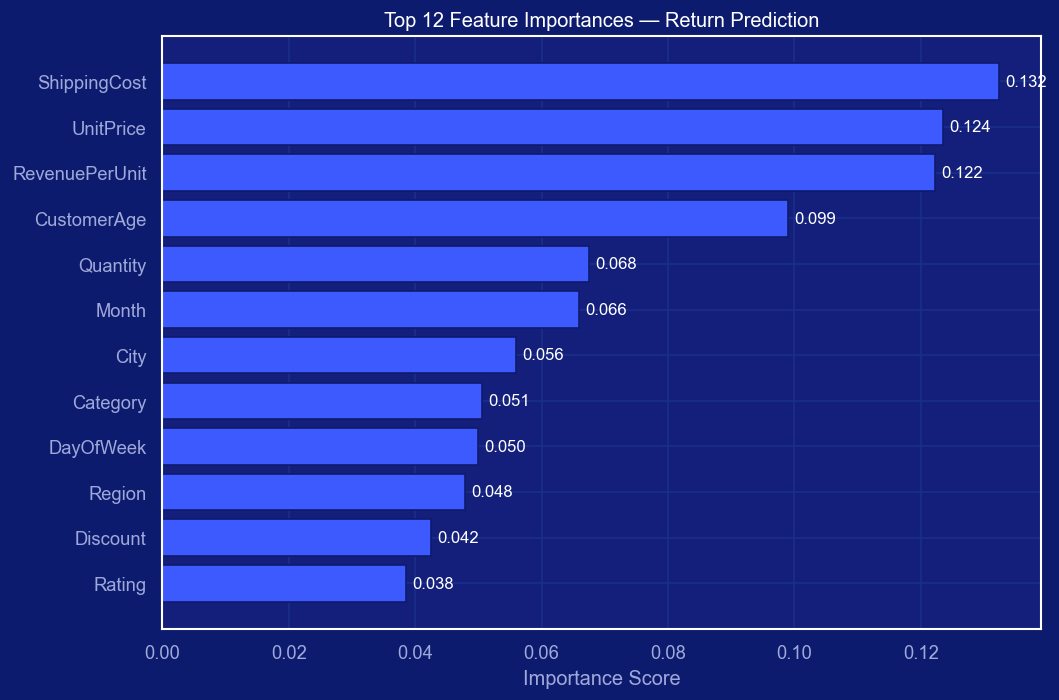


✅ ML pipeline complete — dataset is model-ready!


In [101]:
# Feature importance
fi = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(fi.index, fi.values, color='#3D5AFE', edgecolor='#0D1B6E')
for bar, val in zip(bars, fi.values):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', color='white', fontsize=10)
ax.set_title('Top 12 Feature Importances — Return Prediction')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

print("\n✅ ML pipeline complete — dataset is model-ready!")

---
## 🎓 Session Summary

| Step | What We Did |
|------|-------------|
| **Missing Values** | Detected with `missingno`, imputed Age/Rating/ShippingCost, dropped 40 Region rows |
| **Duplicates** | Found & removed 18 duplicate rows, standardised category strings |
| **Outliers** | IQR fencing on Revenue, Isolation Forest on Revenue × UnitPrice, quantile binning |
| **Univariate EDA** | Histograms, boxplots, value counts across all 18 columns |
| **Bivariate EDA** | Revenue by Category/Channel/Region, Return rate patterns |
| **Multivariate** | Category × Channel pivot, pairplot, FacetGrid |
| **Correlation** | Pearson + Spearman heatmaps — Profit/Revenue strongest pair |
| **Insights** | North leads revenue, Electronics best margin, Online fastest growing |
| **ML Pipeline** | Feature engineering, encoding, scaling, train/test split, Random Forest baseline |

### 🔗 Next Steps
- Try this on a **Zindi Africa** competition dataset → [zindi.africa/competitions](https://zindi.africa)
- Explore `SHAP` for model explainability
- Build a Streamlit dashboard from your cleaned dataset
